<a href="https://colab.research.google.com/github/Natothatbil/SIT-UofG-QC/blob/main/QC_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 85.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=00707c638d6a98b0ce36a26a7c464f03048143f314e5d0359220efbb141f03c8
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


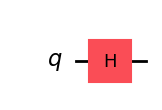

In [ ]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [ ]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [ ]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [ ]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [ ]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

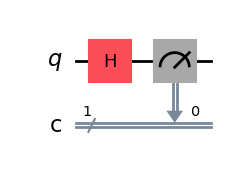

In [ ]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [ ]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [ ]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'1': 509, '0': 515}


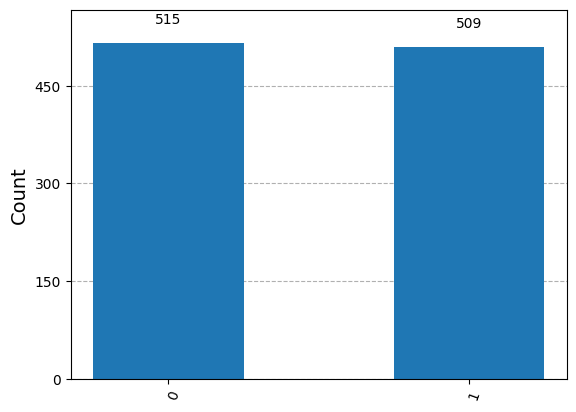

In [ ]:
# We can also produce a graph

plot_histogram(counts)

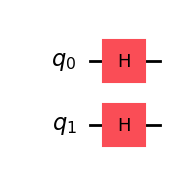

In [ ]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [ ]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

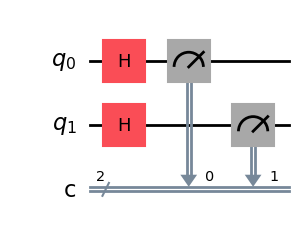

In [ ]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

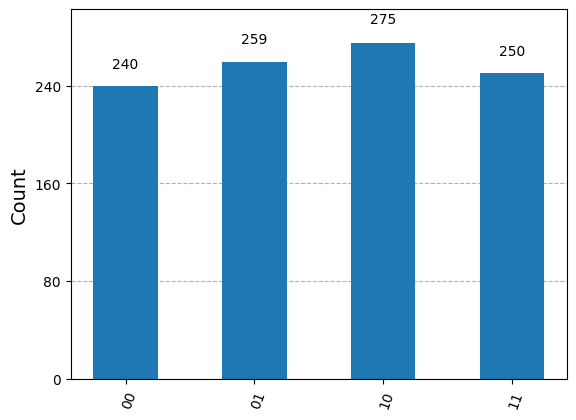

In [ ]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

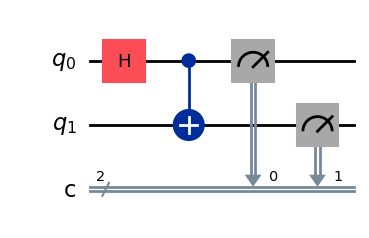

In [ ]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

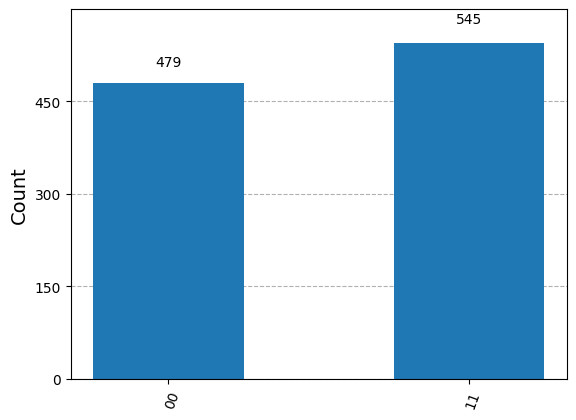

In [ ]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

In [ ]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

The four Bell states are:

1.  **|Φ+⟩ (Phi Plus)**: `1/√2 (|00⟩ + |11⟩)` (already created in the previous example)
2.  **|Φ-⟩ (Phi Minus)**: `1/√2 (|00⟩ - |11⟩)`
3.  **|Ψ+⟩ (Psi Plus)**: `1/√2 (|01⟩ + |10⟩)`
4.  **|Ψ-⟩ (Psi Minus)**: `1/√2 (|01⟩ - |10⟩)`

Let's implement each of them, check their state vectors, and simulate the measurements.

### Bell State 1: |Φ+⟩ = 1/√2 (|00⟩ + |11⟩)

This is the same circuit as before, but re-run here for context.

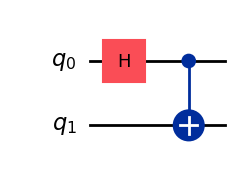

In [ ]:
# Circuit for |Φ+⟩ = 1/√2 (|00⟩ + |11⟩)
circuit_phi_plus = QuantumCircuit(2)
circuit_phi_plus.h(0)
circuit_phi_plus.cx(0,1)

# Display the circuit
circuit_phi_plus.draw("mpl")

In [ ]:
# Display the state vector for |Φ+⟩
state_phi_plus = Statevector.from_int(0, 4)
state_phi_plus = state_phi_plus.evolve(circuit_phi_plus)
state_phi_plus.draw("latex")

<IPython.core.display.Latex object>

Measurement counts for |Φ+⟩: {'00': 533, '11': 491}


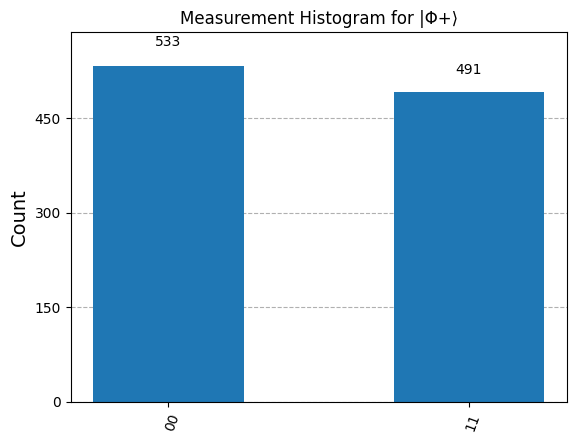

In [ ]:
# Simulate measurements for |Φ+⟩
circuit_phi_plus_meas = circuit_phi_plus.copy()
circuit_phi_plus_meas.measure_all()

qc_compiled_phi_plus = transpile(circuit_phi_plus_meas, backend)
job_sim_phi_plus = backend.run(qc_compiled_phi_plus, shots=1024)
result_sim_phi_plus = job_sim_phi_plus.result()
counts_phi_plus = result_sim_phi_plus.get_counts(qc_compiled_phi_plus)

print(f"Measurement counts for |Φ+⟩: {counts_phi_plus}")
plot_histogram(counts_phi_plus, title='Measurement Histogram for |Φ+⟩')

### Bell State 2: |Φ-⟩ = 1/√2 (|00⟩ - |11⟩)

To get this state from |Φ+⟩, we can apply a Z gate to qubit 0 *before* the Hadamard gate, or after the CNOT on qubit 0. Or, more commonly, apply a Z gate to qubit 1 *after* the CNOT. Let's try applying a Z gate to qubit 0 *before* the Hadamard. Alternatively, we can apply Z on qubit 0 before CNOT (if H is on 0), or Z on qubit 1 after CNOT (if H is on 0).

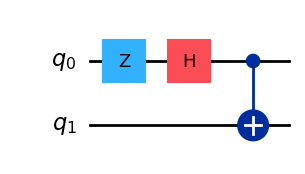

In [ ]:
# Circuit for |Φ-⟩ = 1/√2 (|00⟩ - |11⟩)
circuit_phi_minus = QuantumCircuit(2)
circuit_phi_minus.z(0) # Apply Z gate to qubit 0
circuit_phi_minus.h(0)
circuit_phi_minus.cx(0,1)

# Display the circuit
circuit_phi_minus.draw("mpl")

In [ ]:
# Display the state vector for |Φ-⟩
state_phi_minus = Statevector.from_int(0, 4)
state_phi_minus = state_phi_minus.evolve(circuit_phi_minus)
state_phi_minus.draw("latex")

<IPython.core.display.Latex object>

Measurement counts for |Φ-⟩: {'11': 515, '00': 509}


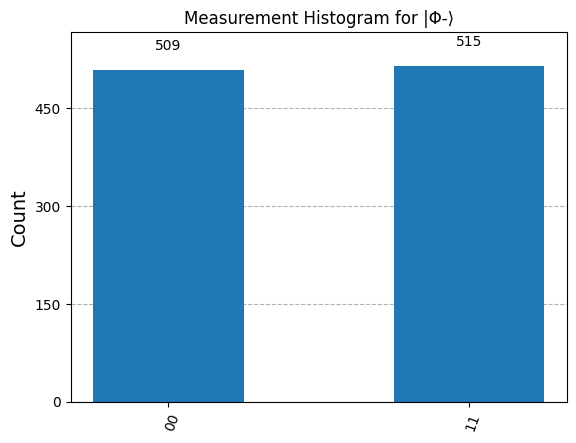

In [ ]:
# Simulate measurements for |Φ-⟩
circuit_phi_minus_meas = circuit_phi_minus.copy()
circuit_phi_minus_meas.measure_all()

qc_compiled_phi_minus = transpile(circuit_phi_minus_meas, backend)
job_sim_phi_minus = backend.run(qc_compiled_phi_minus, shots=1024)
result_sim_phi_minus = job_sim_phi_minus.result()
counts_phi_minus = result_sim_phi_minus.get_counts(qc_compiled_phi_minus)

print(f"Measurement counts for |Φ-⟩: {counts_phi_minus}")
plot_histogram(counts_phi_minus, title='Measurement Histogram for |Φ-⟩')

### Bell State 3: |Ψ+⟩ = 1/√2 (|01⟩ + |10⟩)

To get this state, we can apply an X gate to qubit 1 *before* the |Φ+⟩ circuit (i.e., before the Hadamard on qubit 0 and CNOT).

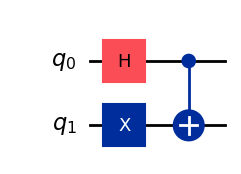

In [ ]:
# Circuit for |Ψ+⟩ = 1/√2 (|01⟩ + |10⟩)
circuit_psi_plus = QuantumCircuit(2)
circuit_psi_plus.x(1) # Apply X gate to qubit 1
circuit_psi_plus.h(0)
circuit_psi_plus.cx(0,1)

# Display the circuit
circuit_psi_plus.draw("mpl")

In [ ]:
# Display the state vector for |Ψ+⟩
state_psi_plus = Statevector.from_int(0, 4)
state_psi_plus = state_psi_plus.evolve(circuit_psi_plus)
state_psi_plus.draw("latex")

<IPython.core.display.Latex object>

Measurement counts for |Ψ+⟩: {'01': 509, '10': 515}


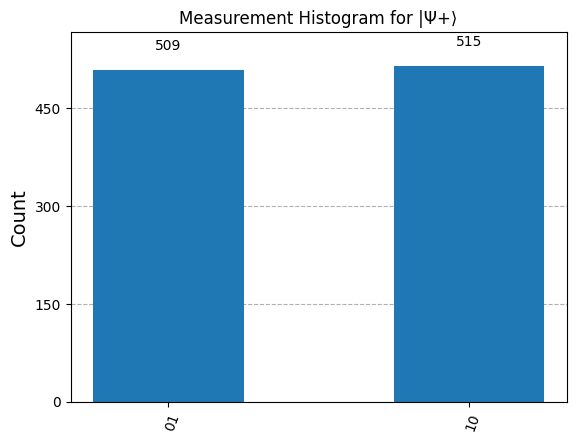

In [ ]:
# Simulate measurements for |Ψ+⟩
circuit_psi_plus_meas = circuit_psi_plus.copy()
circuit_psi_plus_meas.measure_all()

qc_compiled_psi_plus = transpile(circuit_psi_plus_meas, backend)
job_sim_psi_plus = backend.run(qc_compiled_psi_plus, shots=1024)
result_sim_psi_plus = job_sim_psi_plus.result()
counts_psi_plus = result_sim_psi_plus.get_counts(qc_compiled_psi_plus)

print(f"Measurement counts for |Ψ+⟩: {counts_psi_plus}")
plot_histogram(counts_psi_plus, title='Measurement Histogram for |Ψ+⟩')

### Bell State 4: |Ψ-⟩ = 1/√2 (|01⟩ - |10⟩)

To get this state, we can apply an X gate to qubit 1 *before* the |Φ-⟩ circuit (i.e., before the Z on qubit 0, Hadamard on qubit 0, and CNOT).

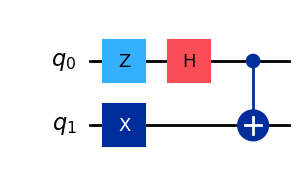

In [ ]:
# Circuit for |Ψ-⟩ = 1/√2 (|01⟩ - |10⟩)
circuit_psi_minus = QuantumCircuit(2)
circuit_psi_minus.x(1) # Apply X gate to qubit 1
circuit_psi_minus.z(0) # Apply Z gate to qubit 0
circuit_psi_minus.h(0)
circuit_psi_minus.cx(0,1)

# Display the circuit
circuit_psi_minus.draw("mpl")

In [ ]:
# Display the state vector for |Ψ-⟩
state_psi_minus = Statevector.from_int(0, 4)
state_psi_minus = state_psi_minus.evolve(circuit_psi_minus)
state_psi_minus.draw("latex")

<IPython.core.display.Latex object>

Measurement counts for |Ψ-⟩: {'10': 528, '01': 496}


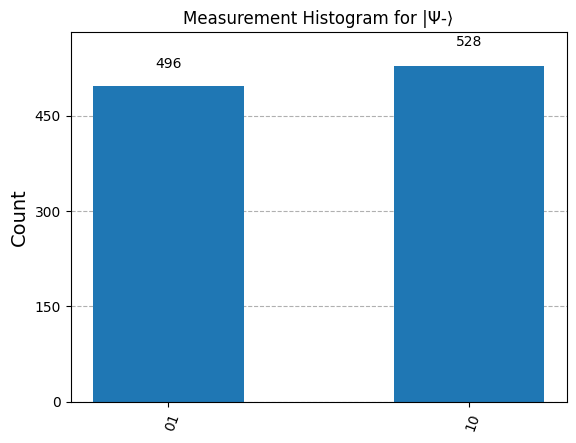

In [ ]:
# Simulate measurements for |Ψ-⟩
circuit_psi_minus_meas = circuit_psi_minus.copy()
circuit_psi_minus_meas.measure_all()

qc_compiled_psi_minus = transpile(circuit_psi_minus_meas, backend)
job_sim_psi_minus = backend.run(qc_compiled_psi_minus, shots=1024)
result_sim_psi_minus = job_sim_psi_minus.result()
counts_psi_minus = result_sim_psi_minus.get_counts(qc_compiled_psi_minus)

print(f"Measurement counts for |Ψ-⟩: {counts_psi_minus}")
plot_histogram(counts_psi_minus, title='Measurement Histogram for |Ψ-⟩')

## GHZ State

The GHZ state for `n` qubits has the form `1/√2 (|00...0⟩ + |11...1⟩)`. The Bell state `1/√2 (|00⟩ + |11⟩)` is a special case of the GHZ state for two qubits.

Let's write a function to construct a circuit that produces a GHZ state for any given number of qubits, simulate it, and then discuss the simulator's limits.

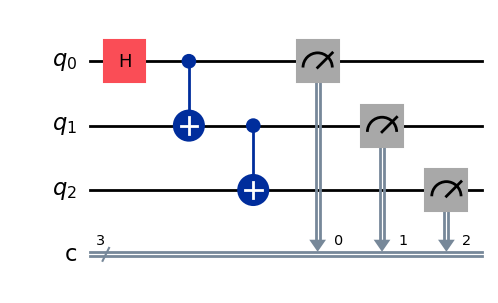

In [ ]:
def create_ghz_circuit(num_qubits):
    """
    Creates a quantum circuit for an n-qubit GHZ state.
    """
    circuit = QuantumCircuit(num_qubits, num_qubits)
    circuit.h(0)
    for i in range(num_qubits - 1):
        circuit.cx(i, i + 1)
    circuit.measure(range(num_qubits), range(num_qubits))
    return circuit

# Let's test with 3 qubits
num_qubits_ghz = 3
ghz_circuit = create_ghz_circuit(num_qubits_ghz)
ghz_circuit.draw("mpl")

Measurement counts for 3-qubit GHZ state: {'000': 524, '111': 500}


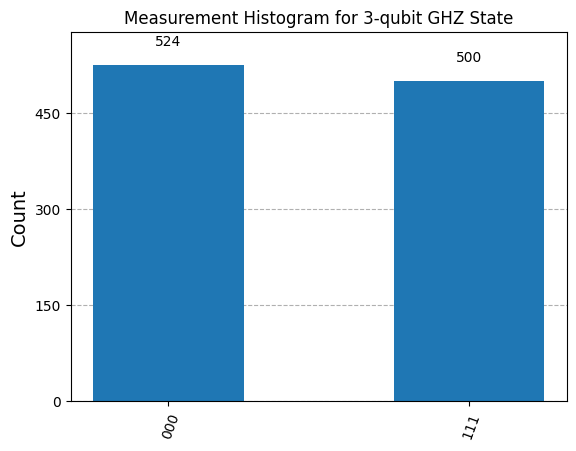

In [ ]:
# Simulate the 3-qubit GHZ circuit
qc_compiled_ghz = transpile(ghz_circuit, backend)
job_sim_ghz = backend.run(qc_compiled_ghz, shots=1024)
result_sim_ghz = job_sim_ghz.result()
counts_ghz = result_sim_ghz.get_counts(qc_compiled_ghz)

print(f"Measurement counts for {num_qubits_ghz}-qubit GHZ state: {counts_ghz}")
plot_histogram(counts_ghz, title=f'Measurement Histogram for {num_qubits_ghz}-qubit GHZ State')

### Simulator Capacity for GHZ States

The `BasicSimulator` backend provided by Qiskit Aer is a local simulator that runs on your machine's CPU. The computational resources required to simulate a quantum circuit grow exponentially with the number of qubits.

Specifically, for `n` qubits, the state vector size is `2^n`. This means:

*   **Memory (RAM):** The state vector requires `2^n * sizeof(complex_double)` bytes. For example, 10 qubits need `2^10 * 16 bytes = 16 KB`, 20 qubits need `2^20 * 16 bytes = 16 MB`, and 30 qubits need `2^30 * 16 bytes = 16 GB`. Beyond this, memory quickly becomes a limiting factor.
*   **Time:** The simulation time for operations (especially multi-qubit gates like CNOTs that affect the entire state vector) also scales roughly with `2^n`.

**To determine how many qubits the simulator can handle in a reasonable time, you can try increasing the `num_qubits_ghz` variable in the `create_ghz_circuit` cell and re-running the cells.**

- On typical personal computers or Colab environments, you might find that the simulator starts to become noticeably slow or runs out of memory around **20-25 qubits**.
- For very simple circuits like the GHZ state (which only involves a Hadamard and CNOTs forming a chain), you might push this limit a bit further than for more complex, highly entangled circuits.

Let me know if you'd like to try simulating a GHZ state with a different number of qubits!

In [ ]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?